In [1]:
import bacco
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [2]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

In [3]:
%load_ext autoreload
%autoreload 2

## Load the MTNG-DM at 1080^3 resolution

In [285]:
del mtng_dm

In [333]:
basedir = "/cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/"

resolution_level = 1

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME
numpart = int(1080**3*2**(3-3*resolution_level))

mtng_dm = bacco.Simulation(basedir=basedir, halo_file="groups_264/fof_subhalo_tab_264", dm_file="snapdir_264/snapshot_264", sim_format='TNG500', fixedPk=True, sigma8=sigma8,\
    tau=tau, ns=ns, numpart=numpart, use_orphans=False, use_ids=False)

pos_mtng = mtng_dm.dm['pos']
pos_mtng[:,0] = (pos_mtng[:,0] - 125)%500


2024-07-08 16:06:21,165 bacco.sims : Initialising simulation Default


2024-07-08 16:06:21,166 bacco.sims : try /cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/snapdir_264/snapshot_264
2024-07-08 16:06:21,170 bacco.sims : Loading /cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/snapdir_264/snapshot_264
2024-07-08 16:06:21,175 bacco.sims : ...done in 0.00971 s
2024-07-08 16:06:29,122 bacco.sims : Read data for 0 42883624/1259712000 particles...
2024-07-08 16:06:33,102 bacco.sims : Read data for 42883624/1259712000 particles...
2024-07-08 16:06:33,105 bacco.sims : Read data for 42883624 43052183/1259712000 particles...
2024-07-08 16:06:37,106 bacco.sims : Read data for 43052183/1259712000 particles...
2024-07-08 16:06:37,109 bacco.sims : Read data for 85935807 40745979/1259712000 particles...
2024-07-08 16:06:40,803 bacco.sims : Read data for 40745979/1259712000 particles...
2024-07-08 16:06:40,806 bacco.sims : Read data for 126681786 42374028/1259712000 particles...
2024-07-08 16:06:44,641 bacco.sims : Read data for 42374028/125971

In [348]:
mtng_halo = mtng_dm.fof['halo_pos']
mtng_halo[:,0] = ( mtng_halo[:,0] - 125 ) % 500 

2024-07-09 14:33:04,839 bacco.sims : Reading 1780958 items for GroupPos


Load the halo selection, which is relative to the 1080 simulation

In [96]:
sel_10 = []
with open("/cosmos_storage/data_sharing/tmp_resims/1080-A/level4/haloes_10/vmax_custom_sel_10.txt", "r") as f:
    for line in f.readlines():
        sel_10.append(int(line))

sel_10 = np.array(sel_10)

In [292]:
halo_pos = mtng_dm.fof['halo_pos'][sel_10]
halo_pos[:,0] = (halo_pos[:,0] - 125)%500

In [288]:
pos_halo = mtng_dm.get_halo_particles(ihalo=sel_10[0], relative=False)
#pos_halo[:,0] = (pos_halo[:,0] - 125)%500

2024-07-08 15:37:13,649 bacco.sims : Reading 1780958 items for Group/GroupLen
2024-07-08 15:37:13,759 bacco.sims : Reading 1780958 items for GroupLen


## Load the ICs

In [84]:
base = "/cosmos_storage/data_sharing/MN5_resims/halos_10/output/"

with h5py.File(base+"/snapdir_000/snapshot_ics_000.0.hdf5", "r") as f:
    print(f['Header'].attrs.keys())
    Nfiles = f['Header'].attrs['NumFilesPerSnapshot']
    Npart = f['Header'].attrs['NumPart_Total']

<KeysViewHDF5 ['BoxSize', 'Git_commit', 'Git_date', 'MassTable', 'NumFilesPerSnapshot', 'NumPart_ThisFile', 'NumPart_Total', 'Redshift', 'Time']>


In [88]:
ic_pos_1 = np.zeros((Npart[1], 3))
ic_pos_2 = np.zeros((Npart[2], 3))
ic_pos_3 = np.zeros((Npart[3], 3))

istart_1 = np.uint64(0)
istart_2 = np.uint64(0)
istart_3 = np.uint64(0)
for ifile in range(Nfiles):
    with h5py.File(base+"/snapdir_000/snapshot_ics_000.{:d}.hdf5".format(ifile), "r") as f:
        npart = f['Header'].attrs['NumPart_ThisFile']
        if npart[1] > 0:
            print("Loading {:d} type 1 particles for file {:d}".format(npart[1], ifile))
            ic_pos_1[istart_1:istart_1+npart[1]] = f['PartType1']['Coordinates'][()]

        if npart[2] > 0:
            print("Loading {:d} type 2 particles for file {:d}".format(npart[2], ifile))
            ic_pos_2[istart_2:istart_2+npart[2]] = f['PartType2']['Coordinates'][()]

        if npart[3] > 0:
            print("Loading {:d} type 3 particles for file {:d}".format(npart[3], ifile))
            ic_pos_3[istart_3:istart_3+npart[3]] = f['PartType3']['Coordinates'][()]

    istart_1 += npart[1]
    istart_2 += npart[2]
    istart_3 += npart[3]

Loading 1298 type 3 particles for file 0
Loading 864 type 3 particles for file 1
Loading 339 type 3 particles for file 2
Loading 1156608 type 1 particles for file 3
Loading 53991 type 2 particles for file 3
Loading 21176 type 3 particles for file 3
Loading 152320 type 1 particles for file 4
Loading 20298 type 2 particles for file 4
Loading 15590 type 3 particles for file 4
Loading 387 type 3 particles for file 5
Loading 95936 type 1 particles for file 6
Loading 11098 type 2 particles for file 6
Loading 7832 type 3 particles for file 6
Loading 758 type 3 particles for file 7
Loading 303 type 3 particles for file 8
Loading 2263 type 3 particles for file 9
Loading 205 type 3 particles for file 10
Loading 366 type 3 particles for file 11
Loading 54784 type 1 particles for file 12
Loading 9202 type 2 particles for file 12
Loading 7350 type 3 particles for file 12
Loading 1017 type 3 particles for file 13
Loading 583 type 3 particles for file 14
Loading 254 type 3 particles for file 15
Loadi

In [90]:
grid_ics1 = bacco.statistics.compute_mesh(pos=ic_pos_1, box=500, ngrid=500)
grid_ics2 = bacco.statistics.compute_mesh(pos=ic_pos_2, box=500, ngrid=500)
grid_ics3 = bacco.statistics.compute_mesh(pos=ic_pos_3, box=500, ngrid=500)

In [ ]:
#base = "/cosmos_storage/data_sharing/tmp_resims/1080-A/level4/haloes_10/hydro_output/"
base = "/cosmos_storage/data_sharing/MN5_resims/halos_10/output/"

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

sim = bacco.Simulation(basedir=base, dm_file="snapdir_000/snapshot_000", sim_format='gadget_hdf5', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, use_ids=False)

## Load the zooms

In [353]:
#base = "/cosmos_storage/data_sharing/tmp_resims/1080-A/level4/haloes_10/hydro_output/"
base = "/cosmos_storage/data_sharing/MN5_resims/halos_10/hydro_output/"

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

sim = bacco.Simulation(basedir=base, halo_file="groups_009/fof_subhalo_tab_009", dm_file="snapdir_009/snapshot_009", sim_format='TNG500', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, use_ids=False)

pos_zoom = sim.dm['pos']

2024-07-09 18:25:15,999 bacco.sims : Initialising simulation Default
2024-07-09 18:25:16,000 bacco.sims : try /cosmos_storage/data_sharing/MN5_resims/halos_10/hydro_output/snapdir_009/snapshot_009
2024-07-09 18:25:16,004 bacco.sims : Loading /cosmos_storage/data_sharing/MN5_resims/halos_10/hydro_output/snapdir_009/snapshot_009


2024-07-09 18:25:16,043 bacco.sims : ...done in 0.0138 s
2024-07-09 18:25:19,164 bacco.sims : Read data for 552285/4415360 particles...
2024-07-09 18:25:19,218 bacco.sims : Read data for 552285/4415360 particles...
2024-07-09 18:25:19,220 bacco.sims : Read data for 531913/4415360 particles...
2024-07-09 18:25:19,268 bacco.sims : Read data for 531913/4415360 particles...
2024-07-09 18:25:19,270 bacco.sims : Read data for 556641/4415360 particles...
2024-07-09 18:25:19,323 bacco.sims : Read data for 556641/4415360 particles...
2024-07-09 18:25:19,326 bacco.sims : Read data for 548950/4415360 particles...


/cosmos_storage/data_sharing/MN5_resims/halos_10/hydro_output/snapdir_009/snapshot_009.0.hdf5


2024-07-09 18:25:19,375 bacco.sims : Read data for 548950/4415360 particles...
2024-07-09 18:25:19,377 bacco.sims : Read data for 556130/4415360 particles...
2024-07-09 18:25:19,433 bacco.sims : Read data for 556130/4415360 particles...
2024-07-09 18:25:19,435 bacco.sims : Read data for 564338/4415360 particles...
2024-07-09 18:25:19,492 bacco.sims : Read data for 564338/4415360 particles...
2024-07-09 18:25:19,494 bacco.sims : Read data for 562467/4415360 particles...
2024-07-09 18:25:19,546 bacco.sims : Read data for 562467/4415360 particles...
2024-07-09 18:25:19,548 bacco.sims : Read data for 542636/4415360 particles...
2024-07-09 18:25:19,601 bacco.sims : Read data for 542636/4415360 particles...
2024-07-09 18:25:19,648 bacco.sims :  DM loading done in 0.486 sec


In [343]:
L_p = 8
z_slab = 10
xmin = np.array([halo_pos[0][0]-L_p/2,halo_pos[0][1]-L_p/2,halo_pos[0][2]-z_slab/2])

mtng_sel = np.where( (pos_mtng[:,0]>(halo_pos[0][0]-L_p/2)) & (pos_mtng[:,0]<(halo_pos[0][0]+L_p/2)) &\
                     (pos_mtng[:,1]>(halo_pos[0][1]-L_p/2)) & (pos_mtng[:,1]<(halo_pos[0][1]+L_p/2)) &\
                     (pos_mtng[:,2]>(halo_pos[0][2]-z_slab/2)) & (pos_mtng[:,0]<(halo_pos[0][2]+z_slab/2)) )[0]

mtng_grid = bacco.statistics.compute_mesh(pos=pos_mtng[mtng_sel] - xmin[np.newaxis,:], box=L_p, ngrid=512)

In [350]:
halo_sel = np.where( (mtng_halo[:,0]>(halo_pos[0][0]-L_p/2)) & (mtng_halo[:,0]<(halo_pos[0][0]+L_p/2)) &\
                     (mtng_halo[:,1]>(halo_pos[0][1]-L_p/2)) & (mtng_halo[:,1]<(halo_pos[0][1]+L_p/2)) &\
                     (mtng_halo[:,2]>(halo_pos[0][2]-z_slab/2)) & (mtng_halo[:,0]<(halo_pos[0][2]+z_slab/2)) &
                     (mtng_dm.fof['halo_m200b']>10) )[0]

2024-07-09 14:34:24,887 bacco.sims : Reading 1780958 items for Group_M_Mean200


In [344]:
halo_grid = bacco.statistics.compute_mesh(pos=pos_halo - xmin[np.newaxis,:], box=L_p, ngrid=512)

In [345]:
zoom_sel = np.where( (pos_zoom[:,0]>(halo_pos[0][0]-L_p/2)) & (pos_zoom[:,0]<(halo_pos[0][0]+L_p/2)) &\
                     (pos_zoom[:,1]>(halo_pos[0][1]-L_p/2)) & (pos_zoom[:,1]<(halo_pos[0][1]+L_p/2)) &\
                     (pos_zoom[:,2]>(halo_pos[0][2]-z_slab/2)) & (pos_zoom[:,0]<(halo_pos[0][2]+z_slab/2)) )[0]

zoom_grid = bacco.statistics.compute_mesh(pos=pos_zoom[zoom_sel] - xmin[np.newaxis,:], box=L_p, ngrid=512)

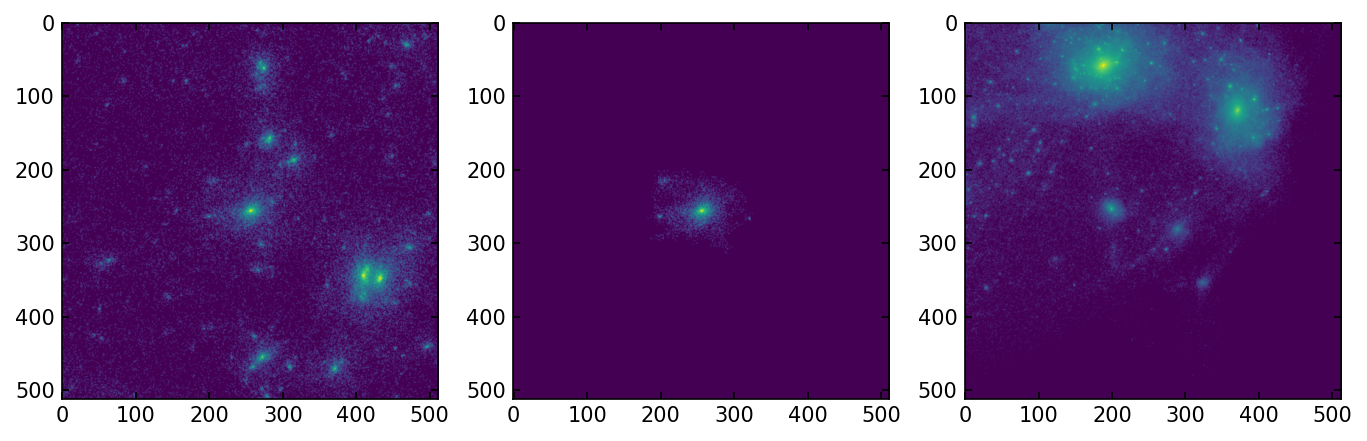

In [347]:
fig, ax = plt.subplots(1,3, dpi=150, figsize=(11,5))

ax[0].imshow(np.log10(1+np.sum(mtng_grid[0,:,:,:],axis=2)))
ax[1].imshow(np.log10(1+np.sum(halo_grid[0,:,:,:],axis=2)))
ax[2].imshow(np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=2)))

for i in range(halo_sel.shape):
    circle = plt.Circle((mtng_halo[halo_sel][i,1],mtng_halo[halo_sel][i,0]), mtng_dm.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    ax[1].add_artist(circle)

In [306]:
pos = sim.hy['dm']['pos']
zoom_grid = bacco.statistics.compute_mesh(pos=pos - np.array([25,380,440])[np.newaxis   , :], box=30, ngrid=512)

In [98]:
halo_pos

array([[158.25131 , 397.2463  , 461.02264 ],
       [483.60413 ,  56.266636, 183.8553  ],
       [ 64.90529 , 100.35018 , 265.82855 ],
       [139.22067 , 331.46042 , 265.98975 ],
       [460.11642 , 402.28793 ,  12.94096 ],
       [344.57736 ,  25.491707, 297.92514 ],
       [284.2199  , 271.80835 , 219.29013 ],
       [329.99432 , 491.3519  ,  42.82367 ],
       [295.1158  , 425.28735 ,  76.22827 ],
       [301.93088 , 346.14047 , 306.3655  ]], dtype=float32)

Text(0, 0.5, '$x$')

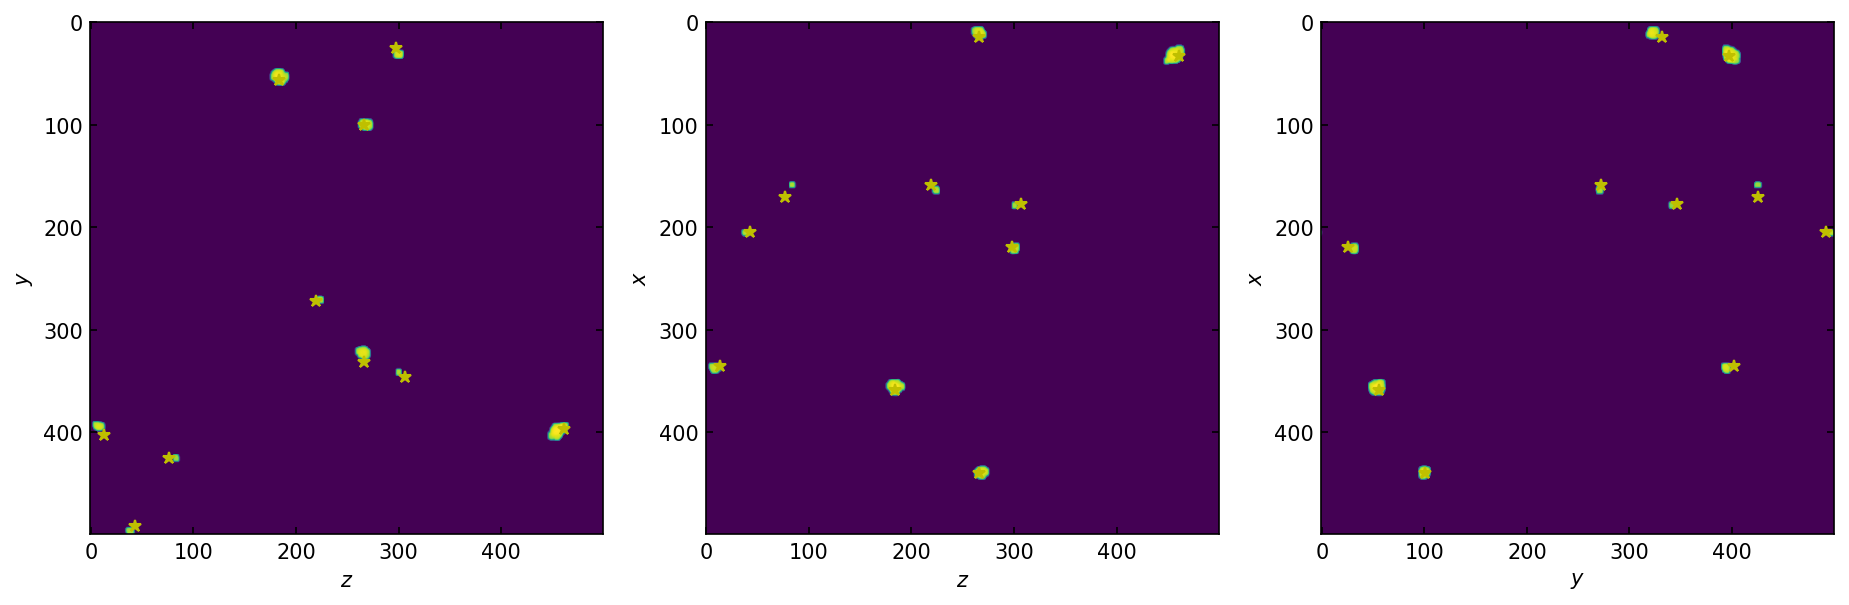

In [101]:
fig, ax = plt.subplots(1,3,figsize=(15,5), dpi=150)

ax[0].imshow( np.log10(1+np.sum(grid_ics1[0,:,:,:],axis=0)) )
ax[0].plot(halo_pos[:,2], halo_pos[:,1], marker='*', color='y', ls='')
ax[0].set_xlabel('$z$')
ax[0].set_ylabel('$y$')

ax[1].imshow( np.log10(1+np.sum(grid_ics1[0,:,:,:],axis=1)) )
ax[1].plot(halo_pos[:,2], (halo_pos[:,0]-125)%500, marker='*', color='y', ls='')
ax[1].set_xlabel('$z$')
ax[1].set_ylabel('$x$')

ax[2].imshow( np.log10(1+np.sum(grid_ics1[0,:,:,:],axis=2)) )
ax[2].plot(halo_pos[:,1], (halo_pos[:,0]-125)%500, marker='*', color='y', ls='')
ax[2].set_xlabel('$y$')
ax[2].set_ylabel('$x$')


Text(0, 0.5, '$x$')

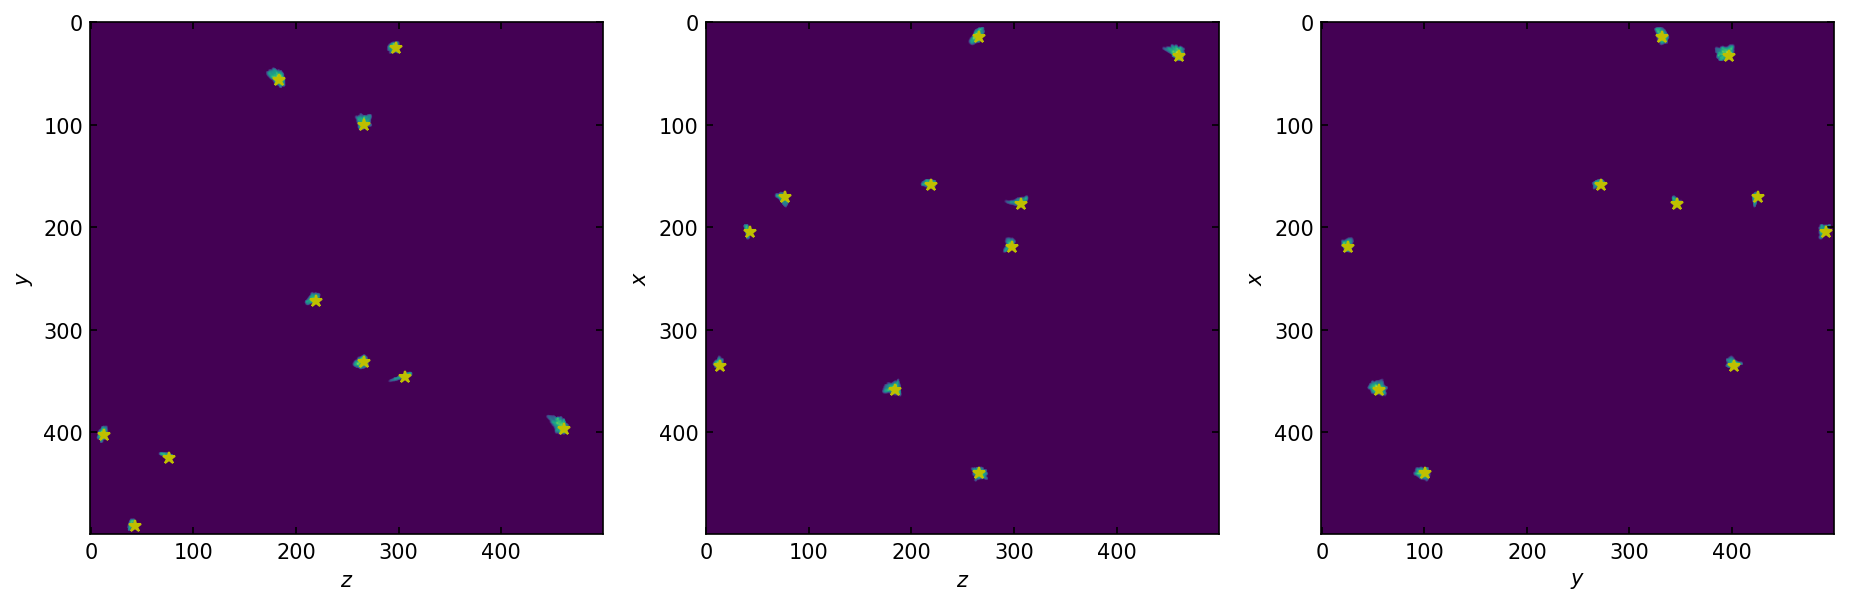

In [102]:
fig, ax = plt.subplots(1,3,figsize=(15,5), dpi=150)

ax[0].imshow( np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=0)) )
ax[0].plot(halo_pos[:,2], halo_pos[:,1], marker='*', color='y', ls='')
ax[0].set_xlabel('$z$')
ax[0].set_ylabel('$y$')

ax[1].imshow( np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=1)) )
ax[1].plot(halo_pos[:,2], (halo_pos[:,0]-125)%500, marker='*', color='y', ls='')
ax[1].set_xlabel('$z$')
ax[1].set_ylabel('$x$')

ax[2].imshow( np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=2)) )
ax[2].plot(halo_pos[:,1], (halo_pos[:,0]-125)%500, marker='*', color='y', ls='')
ax[2].set_xlabel('$y$')
ax[2].set_ylabel('$x$')


Text(0, 0.5, '$x$')

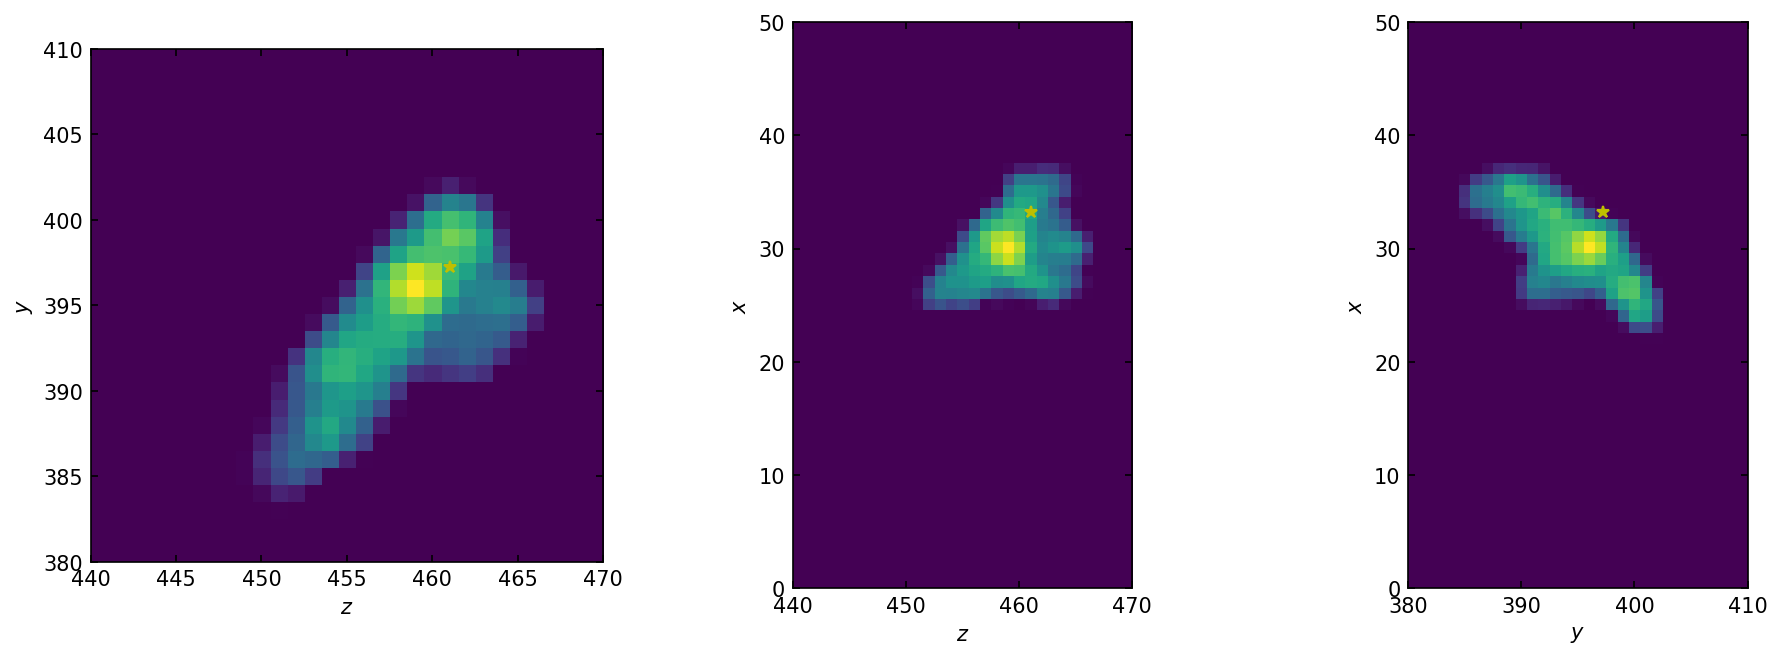

In [116]:
fig, ax = plt.subplots(1,3,figsize=(15,5), dpi=150)

ax[0].set_ylim(380,410)
ax[0].set_xlim(440,470)

ax[1].set_ylim(0,50)
ax[1].set_xlim(440,470)

ax[2].set_ylim(0,50)
ax[2].set_xlim(380,410)

ax[0].imshow( np.log10(1+zoom_grid[0,30,:,:]) )
ax[0].plot(halo_pos[:,2], halo_pos[:,1], marker='*', color='y', ls='')
ax[0].set_xlabel('$z$')
ax[0].set_ylabel('$y$')

ax[1].imshow( np.log10(1+zoom_grid[0,:,395,:]) )
ax[1].plot(halo_pos[:,2], (halo_pos[:,0]-125)%500, marker='*', color='y', ls='')
ax[1].set_xlabel('$z$')
ax[1].set_ylabel('$x$')

ax[2].imshow( np.log10(1+zoom_grid[0,:,:,458]) )
ax[2].plot(halo_pos[:,1], (halo_pos[:,0]-125)%500, marker='*', color='y', ls='')
ax[2].set_xlabel('$y$')
ax[2].set_ylabel('$x$')

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(15,5), dpi=150)

ax[0].set_ylim(380,410)
ax[0].set_xlim(440,470)

ax[1].set_ylim(0,50)
ax[1].set_xlim(440,470)

ax[2].set_ylim(0,50)
ax[2].set_xlim(380,410)

ax[0].imshow( np.log10(1+zoom_grid[0,30,:,:]) )
ax[0].plot(halo_pos[:,2], halo_pos[:,1], marker='*', color='y', ls='')
ax[0].set_xlabel('$z$')
ax[0].set_ylabel('$y$')

ax[1].imshow( np.log10(1+zoom_grid[0,:,395,:]) )
ax[1].plot(halo_pos[:,2], (halo_pos[:,0]-125)%500, marker='*', color='y', ls='')
ax[1].set_xlabel('$z$')
ax[1].set_ylabel('$x$')

ax[2].imshow( np.log10(1+zoom_grid[0,:,:,458]) )
ax[2].plot(halo_pos[:,1], (halo_pos[:,0]-125)%500, marker='*', color='y', ls='')
ax[2].set_xlabel('$y$')
ax[2].set_ylabel('$x$')


In [ ]:
fig, ax = plt.subplots(1,3,figsize=(15,5), dpi=150)

ax[0].set_ylim(380,410)
ax[0].set_xlim(440,470)

ax[1].set_ylim(0,50)
ax[1].set_xlim(440,470)

ax[2].set_ylim(0,50)
ax[2].set_xlim(380,410)

ax[0].imshow( np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=0)) )
ax[0].plot(halo_pos[:,2], halo_pos[:,1], marker='*', color='y', ls='')
ax[0].set_xlabel('$z$')
ax[0].set_ylabel('$y$')

ax[1].imshow( np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=1)) )
ax[1].plot(halo_pos[:,2], (halo_pos[:,0]-125)%500, marker='*', color='y', ls='')
ax[1].set_xlabel('$z$')
ax[1].set_ylabel('$x$')

ax[2].imshow( np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=2)) )
ax[2].plot(halo_pos[:,1], (halo_pos[:,0]-125)%500, marker='*', color='y', ls='')
ax[2].set_xlabel('$y$')
ax[2].set_ylabel('$x$')


### Let's see what are the properties of these halos

In [78]:
m200b = 1e10*sim.fof['halo_m200b']
mfof = 1e10*sim.fof['halo_mfof_type'][:,1]

group_len = sim.fof['halo_len']

2024-07-05 14:24:04,102 bacco.sims : Reading 5942 items for GroupLen


Text(0, 0.5, 'Counts')

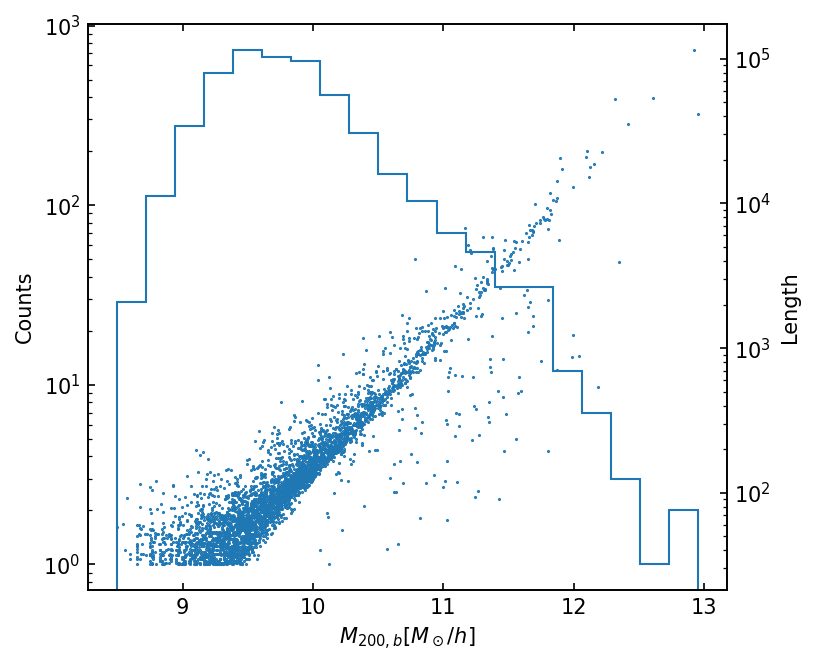

In [23]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.hist(np.log10(m200b[np.where(m200b>0)]), bins=20, log=True, histtype='step')
ax2 = ax.twinx()
ax2.plot(np.log10(m200b[np.where(m200b>0)]), group_len[np.where(m200b>0)], marker='o', ls='', ms=0.5)
ax2.set_ylabel('Length')
ax2.set_yscale('log')

ax.set_xlabel('$M_{200,b}[M_\odot/h]$')
ax.set_ylabel('Counts')

Text(0, 0.5, 'Counts')

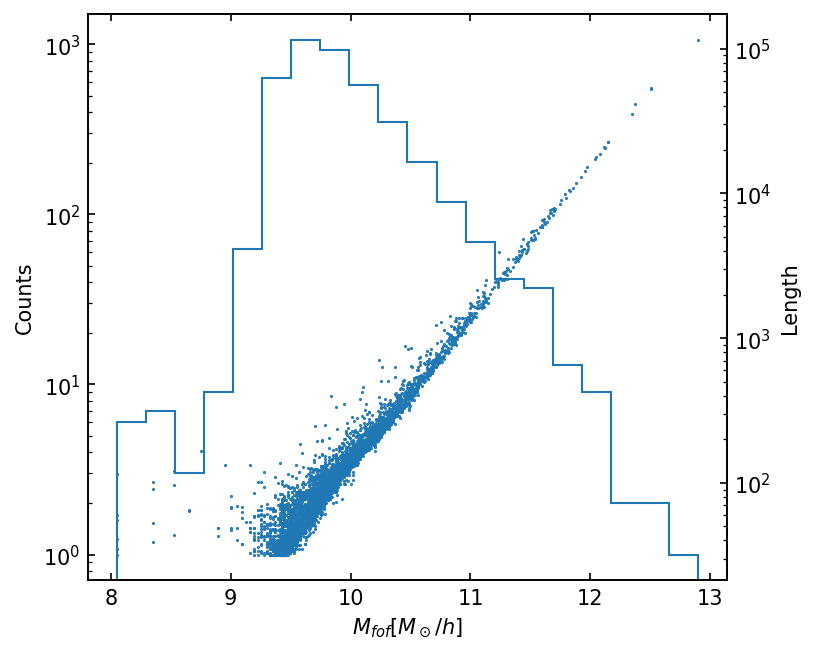

In [79]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.hist(np.log10(mfof[np.where(m200b>0)]), bins=20, log=True, histtype='step')
ax2 = ax.twinx()
ax2.plot(np.log10(mfof[np.where(m200b>0)]), group_len[np.where(m200b>0)], marker='o', ls='', ms=0.5)
ax2.set_ylabel('Length')
ax2.set_yscale('log')

ax.set_xlabel('$M_{fof}[M_\odot/h]$')
ax.set_ylabel('Counts')

#### Cross-match selected halos with zoomed ones

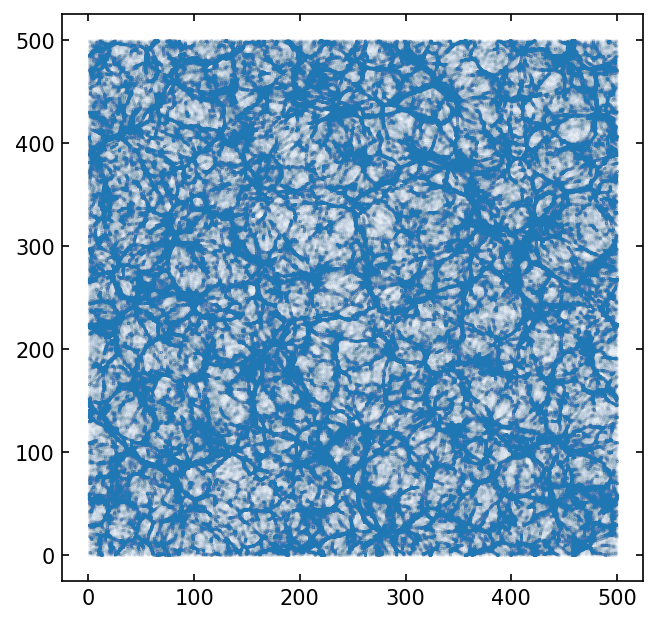

In [28]:
fig, ax = plt.subplots(dpi=150, figsize=(5,5))

ax.plot(pos_sel[:,0],pos_sel[:,1], ms=0.005, ls='', marker='o')


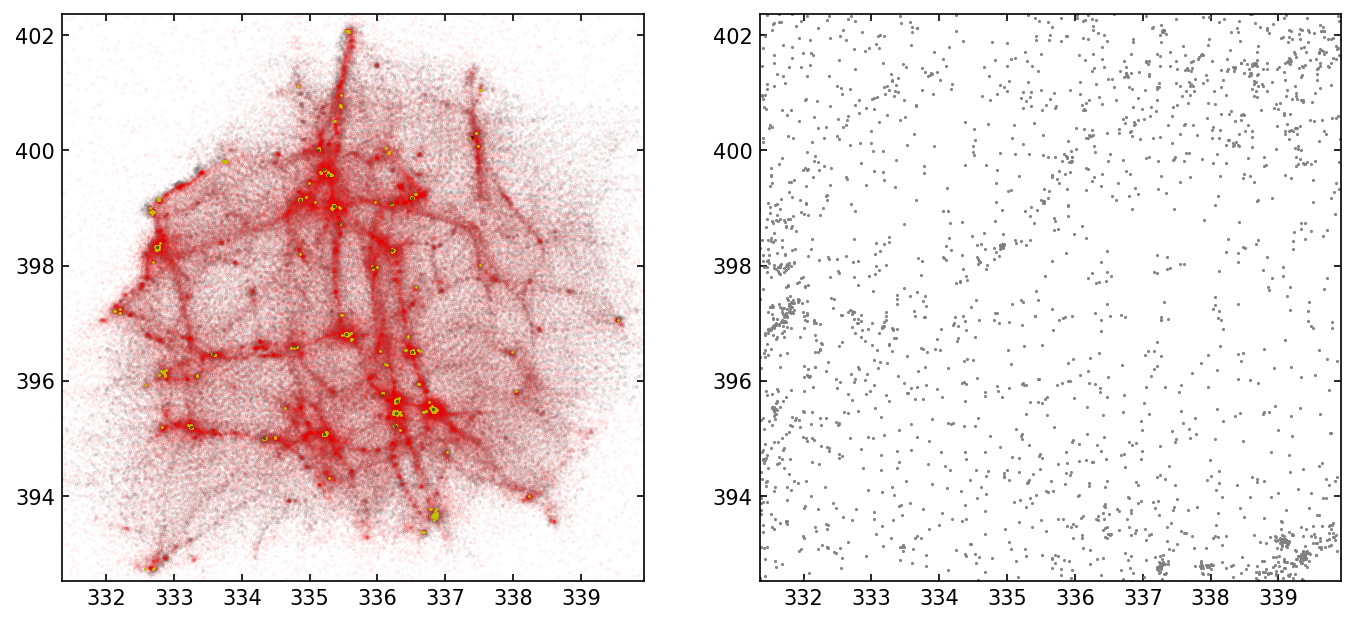

In [32]:
fig, ax = plt.subplots(1, 2, dpi=150, figsize=(11, 5))

def select(pos, zmin, zmax):
    sel = np.where((pos[:,2]<zmax) & (pos[:,2]>zmin))[0]
    return pos[sel,:]

gas_sel = select(sim.hy['gas']['pos'], 0, 10)
star_sel = select(sim.hy['star']['pos'], 0, 10)
bh_sel = select(sim.hy['bh']['pos'], 0, 10)
dm_sel = select(sim.hy['dm']['pos'], 0, 10)

ax[0].set_xlim(dm_sel[:,0].min(), dm_sel[:,0].max())
ax[0].set_ylim(dm_sel[:,1].min(), dm_sel[:,1].max())

ax[0].plot(dm_sel[:,0], dm_sel[:,1], marker='.', ls='', ms=0.1, color='gray')
ax[0].plot(gas_sel[:,0], gas_sel[:,1], marker='.', ls='', ms=0.05, color='r')
ax[0].plot(star_sel[:,0], star_sel[:,1], marker='*', ls='', ms=0.8, color='y')
ax[0].plot(bh_sel[:,0], bh_sel[:,1], marker='o', ls='', ms=0.3, color='k')

pos = mtng_dm.dm['pos']
pos[:,0] -= 125
pos = pos % 500

pos_sel = select(pos, 0, 10)

ax[1].set_xlim(dm_sel[:,0].min(), dm_sel[:,0].max())
ax[1].set_ylim(dm_sel[:,1].min(), dm_sel[:,1].max())

ax[1].plot(pos_sel[:,0], pos_sel[:,1], marker='.', ls='', ms=1, color='gray')



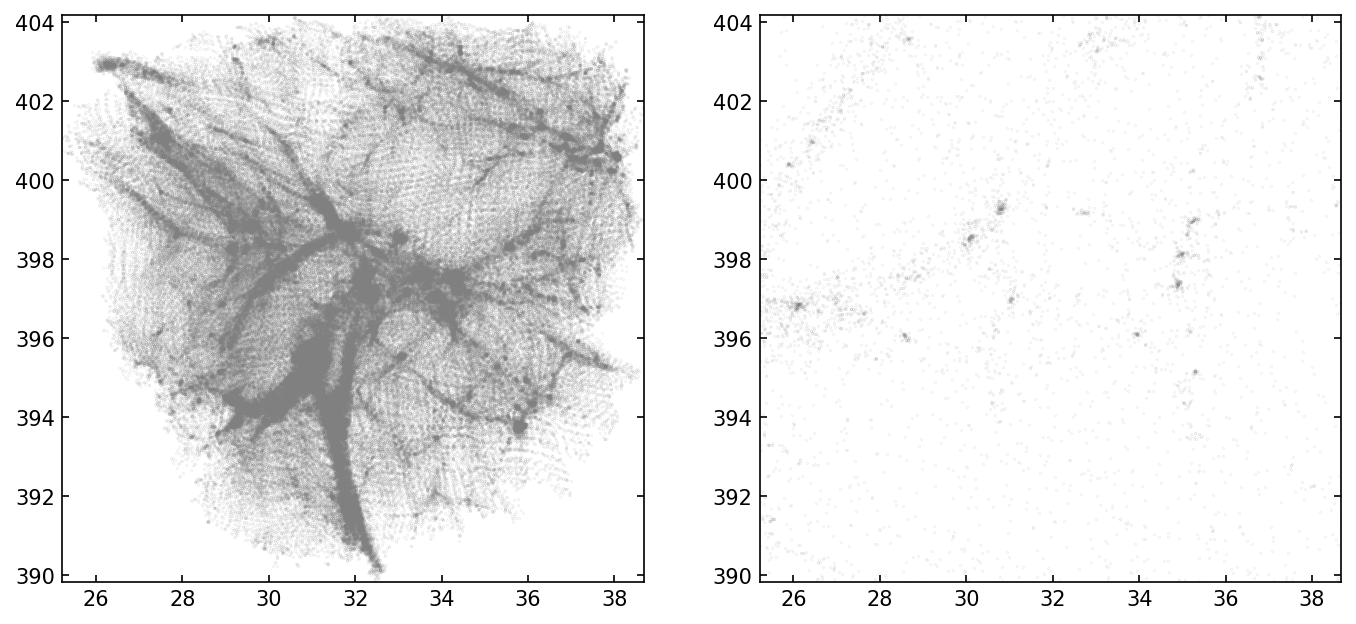

In [36]:
fig, ax = plt.subplots(1, 2, dpi=150, figsize=(11,5))

def select(pos, zmin, zmax):
    sel = np.where((pos[:,2]<zmax) & (pos[:,2]>zmin))[0]
    return pos[sel,:]

gas_sel = select(sim.hy['gas']['pos'], 450, 455)
star_sel = select(sim.hy['star']['pos'], 450, 455)
bh_sel = select(sim.hy['bh']['pos'], 450, 455)
dm_sel = select(sim.hy['dm']['pos'], 450, 455)

ax[0].set_xlim(dm_sel[:,0].min(), dm_sel[:,0].max())
ax[0].set_ylim(dm_sel[:,1].min(), dm_sel[:,1].max())

ax[0].plot(dm_sel[:,0], dm_sel[:,1], marker='.', ls='', ms=0.1, color='gray')
# ax[0].plot(gas_sel[:,0], gas_sel[:,1], marker='.', ls='', ms=0.05, color='r')
# ax[0].plot(star_sel[:,0], star_sel[:,1], marker='*', ls='', ms=0.8, color='y')
# ax[0].plot(bh_sel[:,0], bh_sel[:,1], marker='o', ls='', ms=0.3, color='k')

pos_sel = select(pos, 450, 455)

ax[1].set_xlim(dm_sel[:,0].min(), dm_sel[:,0].max())
ax[1].set_ylim(dm_sel[:,1].min(), dm_sel[:,1].max())

ax[1].plot(pos_sel[:,0], pos_sel[:,1], marker='.', ls='', ms=0.1, color='gray')


